# Insurance Claims Intelligence
## Life Claims Intelligence — Exploratory Data Analysis

### Phase 4: Exploratory Data Analysis

**Data Period:** FY 2020-21 to FY 2024-25  
**Data Source:** IRDAI — Handbook on Indian Insurance Statistics  
**Analysis Level:** Insurer-Year

---

### Project Objective

This analysis investigates whether the headline claim settlement ratio
adequately represents claims reliability.

The analysis goes beyond claim-count settlement by examining:

- Count-based Claim Settlement Ratio
- Value-based Claim Settlement Ratio
- Count–Value Gap
- Repudiation Rate
- Pending Rate
- Long-Pending Share
- Unclaimed Ratio

The objective is to identify meaningful patterns in insurer-level
claims settlement performance, consistency, unresolved claims and
customer-facing outcomes.

> **Important:** This analysis is based on publicly available
> regulatory data and represents an independent analytical study.

----

## Phase 4 — EDA Roadmap

The analysis is structured around a small number of
business-driven questions rather than descriptive charts alone.

### Business Questions

1. Does claim settlement performance look materially different
   when measured by claim value instead of claim count?

2. Which insurers show persistent claim-value underperformance
   across the five-year period?

3. Is a higher pending rate associated with a larger share of
   long-pending claims?

4. Are settlement ratios less stable for insurers with lower
   claim volumes?

5. Has the unclaimed-claim ratio improved or deteriorated
   over the five-year period?

6. Do insurers with larger Count–Value Gaps also show weaker
   outcomes in repudiation, pending or unclaimed claims?




-----

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Load Phase 3 dataset

In [2]:
df = pd.read_csv(r"D:\My Projects\Insurance_Claims_Intelligence\data\clean\Life_Claims_Feature_Engineered.csv")
df

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate
0,2020-21,LIC,5875,349.690000,941101,18755.650000,946976,19105.340000,933889,18295.580000,...,0.0,0.0,False,98.618022,95.761604,2.856418,1.237821,0.182159,0.000000,0.689669
1,2020-21,Aditya Birla Sun Life,19,3.802883,6455,468.846357,6474,472.649240,6347,440.264288,...,0.0,0.0,False,98.038307,93.148206,4.890101,0.000000,0.169910,0.000000,1.791783
2,2020-21,Bandhan,0,0.000000,401,107.440000,401,107.440000,398,105.980000,...,0.0,0.0,True,99.251870,98.641102,0.610768,0.000000,0.000000,NaN,0.748130
3,2020-21,Ageas Federal,5,1.255000,1800,87.051683,1805,88.306683,1716,73.848647,...,0.0,0.0,False,95.069252,83.627473,11.441779,0.000000,2.770083,0.000000,2.105263
4,2020-21,Aviva,5,0.778359,1050,116.371251,1055,117.149610,1034,111.572118,...,0.0,0.0,False,98.009479,95.239000,2.770478,0.000000,0.000000,NaN,1.990521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2024-25,Sahara,0,0.000000,0,0.000000,0,0.000000,0,0.000000,...,0.0,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,2024-25,SBI Life,118,23.580493,44831,2598.751947,44949,2622.332439,44205,2497.939508,...,34.0,2.0,False,98.344791,95.256401,3.088390,0.290204,0.367083,1.212121,1.165766
119,2024-25,Shriram,6,0.294771,4846,180.195625,4852,180.490395,4770,147.476986,...,0.0,0.0,False,98.309975,81.709049,16.600926,0.000000,0.144270,0.000000,1.401484
120,2024-25,Star Union,3,0.805000,2410,144.384758,2413,145.189758,2385,140.738808,...,0.0,0.0,False,98.839619,96.934391,1.905228,0.000000,0.082884,0.000000,1.077497


### Validate

In [3]:
df.shape 

(122, 30)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FY                    122 non-null    str    
 1   Insurer               122 non-null    str    
 2   pending_start_count   122 non-null    int64  
 3   pending_start_amount  122 non-null    float64
 4   intimated_count       122 non-null    int64  
 5   intimated_amount      122 non-null    float64
 6   total_claims_count    122 non-null    int64  
 7   total_claims_amount   122 non-null    float64
 8   paid_count            122 non-null    int64  
 9   paid_amount           122 non-null    float64
 10  repudiated_count      122 non-null    int64  
 11  repudiated_amount     122 non-null    float64
 12  rejected_count        122 non-null    int64  
 13  rejected_amount       122 non-null    float64
 14  unclaimed_count       122 non-null    int64  
 15  unclaimed_amount      122 non-null

### Analytical columns

In [5]:
df[
    [
        "FY",
        "Insurer",
        "Low_Volume_Flag",
        "Count_CSR",
        "Value_CSR",
        "Count_Value_Gap",
        "Repudiation_Rate",
        "Pending_Rate",
        "Long_Pending_Share",
        "Unclaimed_Ratio"
    ]
].head()

,FY,Insurer,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Repudiation_Rate,Pending_Rate,Long_Pending_Share,Unclaimed_Ratio
0,2020-21,LIC,False,98.618022,95.761604,2.856418,0.689669,0.182159,0.0,1.237821
1,2020-21,Aditya Birla Sun Life,False,98.038307,93.148206,4.890101,1.791783,0.169910,0.0,0.000000
2,2020-21,Bandhan,True,99.251870,98.641102,0.610768,0.748130,0.000000,NaN,0.000000
3,2020-21,Ageas Federal,False,95.069252,83.627473,11.441779,2.105263,2.770083,0.0,0.000000
4,2020-21,Aviva,False,98.009479,95.239000,2.770478,1.990521,0.000000,NaN,0.000000


### EDA data-quality gate

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDuplicate FY + Insurer:")
print(df.duplicated(["FY", "Insurer"]).sum())

print("\nMissing values in analytical metrics:")
print(
    df[
        [
            "Count_CSR",
            "Value_CSR",
            "Count_Value_Gap",
            "Repudiation_Rate",
            "Pending_Rate",
            "Long_Pending_Share",
            "Unclaimed_Ratio"
        ]
    ].isna().sum()
)

Rows: 122
Columns: 30

Duplicate FY + Insurer:
0

Missing values in analytical metrics:
Count_CSR              6
Value_CSR              6
Count_Value_Gap        6
Repudiation_Rate       6
Pending_Rate           6
Long_Pending_Share    38
Unclaimed_Ratio        6
dtype: int64


### Coverage

In [7]:
print("Financial Years:")
print(sorted(df["FY"].unique()))

print("\nNumber of insurers:")
print(df["Insurer"].nunique())

print("\nObservations per FY:")
print(df.groupby("FY")["Insurer"].nunique())

Financial Years:
['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']

Number of insurers:
27

Observations per FY:
FY
2020-21    24
2021-22    24
2022-23    23
2023-24    25
2024-25    26
Name: Insurer, dtype: int64


### Low-volume observation

In [8]:
df["Low_Volume_Flag"].value_counts(dropna=False)

Low_Volume_Flag
False    111
True      11
Name: count, dtype: int64

In [9]:
df.groupby("Low_Volume_Flag")[
    ["Count_CSR", "Value_CSR", "Count_Value_Gap"]
].median()

,Count_CSR,Value_CSR,Count_Value_Gap
Low_Volume_Flag,,,
False,98.500682,95.256401,3.088390
True,99.367089,98.641102,0.001533


----

## Q1 — Count vs Value Settlement Divergence

### Business Question

Does claim settlement performance look materially different
when measured by claim value instead of claim count?

### Objective

To determine whether the headline count-based settlement ratio
provides the same picture as value-based settlement performance.

### Why This Matters

A high proportion of claims may be settled by count while a
meaningfully smaller proportion of claim value is settled.

Therefore, evaluating both dimensions can reveal differences
that a count-based CSR alone may not capture.

### Metrics

- Count_CSR
- Value_CSR
- Count_Value_Gap

----

### Analysis 1: Overall comparison

In [10]:
df.head(5)

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate
0,2020-21,LIC,5875,349.690000,941101,18755.650000,946976,19105.340000,933889,18295.580000,...,0.0,0.0,False,98.618022,95.761604,2.856418,1.237821,0.182159,0.0,0.689669
1,2020-21,Aditya Birla Sun Life,19,3.802883,6455,468.846357,6474,472.649240,6347,440.264288,...,0.0,0.0,False,98.038307,93.148206,4.890101,0.000000,0.169910,0.0,1.791783
2,2020-21,Bandhan,0,0.000000,401,107.440000,401,107.440000,398,105.980000,...,0.0,0.0,True,99.251870,98.641102,0.610768,0.000000,0.000000,NaN,0.748130
3,2020-21,Ageas Federal,5,1.255000,1800,87.051683,1805,88.306683,1716,73.848647,...,0.0,0.0,False,95.069252,83.627473,11.441779,0.000000,2.770083,0.0,2.105263
4,2020-21,Aviva,5,0.778359,1050,116.371251,1055,117.149610,1034,111.572118,...,0.0,0.0,False,98.009479,95.239000,2.770478,0.000000,0.000000,NaN,1.990521


In [11]:
q1_summary = df[
    ["Count_CSR", "Value_CSR", "Count_Value_Gap"]
].describe()

q1_summary

,Count_CSR,Value_CSR,Count_Value_Gap
count,116.000000,116.000000,116.000000
mean,97.365970,93.212092,4.153878
std,9.202453,9.924512,4.046813
min,0.000000,0.000000,-0.297851
25%,97.856519,92.744876,1.689739
50%,98.518600,95.324729,2.999698
75%,99.093611,96.976318,5.516924
max,99.726027,99.798183,19.773667


In [12]:
df[
    ["Count_CSR", "Value_CSR", "Count_Value_Gap"]
].median()

Count_CSR          98.518600
Value_CSR          95.324729
Count_Value_Gap     2.999698
dtype: float64

### chart 

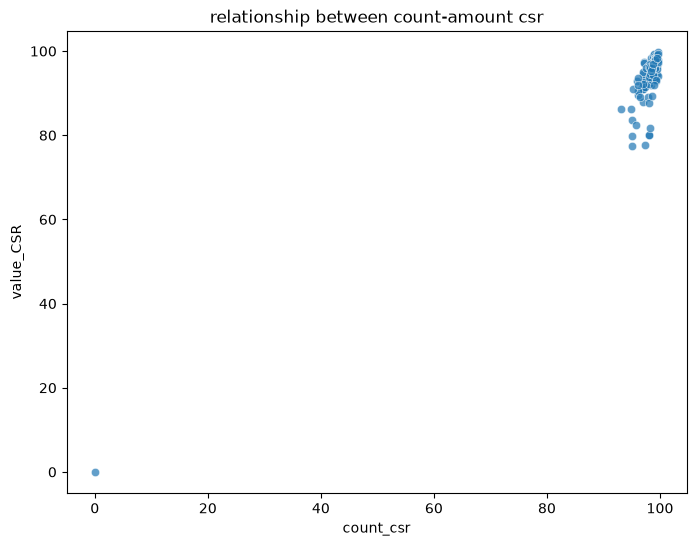

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Count_CSR"],
    y=df["Value_CSR"],
    alpha = 0.7
)

plt.xlabel("count_csr")
plt.ylabel("value_CSR")
plt.title("relationship between count-amount csr")

plt.show()

### ZERO CSR investigation

In [14]:
zero_csr = df[
    (df["Count_CSR"] == 0) |
    (df["Value_CSR"] == 0)
]

zero_csr[
    [
        "FY",
        "Insurer",
        "Low_Volume_Flag",
        "Count_CSR",
        "Value_CSR",
        "Count_Value_Gap"
    ]
]

,FY,Insurer,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap
108,2024-25,Godigit Life,True,0.0,0.0,0.0


In [15]:
df[
    ["Count_CSR", "Value_CSR", "Count_Value_Gap"]
].isna().sum()

Count_CSR          6
Value_CSR          6
Count_Value_Gap    6
dtype: int64

In [16]:
missing_q1 = df[
    df[["Count_CSR", "Value_CSR", "Count_Value_Gap"]]
    .isna()
    .any(axis=1)
]

missing_q1[
    [
        "FY",
        "Insurer",
        "Low_Volume_Flag",
        "Count_CSR",
        "Value_CSR",
        "Count_Value_Gap"
    ]
]

,FY,Insurer,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap
72,2023-24,Acko Life,True,NaN,NaN,NaN
79,2023-24,Credit Access Life,True,NaN,NaN,NaN
83,2023-24,Godigit Life,True,NaN,NaN,NaN
97,2024-25,Acko Life,True,NaN,NaN,NaN
104,2024-25,Credit Access Life,True,NaN,NaN,NaN
117,2024-25,Sahara,True,NaN,NaN,NaN


### treating that zero

In [17]:
q1_df = df[
    df["Count_CSR"].notna() &
    df["Value_CSR"].notna() &
    (df["Count_CSR"] > 0) &
    (df["Value_CSR"] > 0)
].copy()

print("Original observations:", len(df))
print("Q1 valid observations:", len(q1_df))
print("Excluded observations:", len(df) - len(q1_df))

Original observations: 122
Q1 valid observations: 115
Excluded observations: 7


In [18]:
q1_df[
    ["Count_CSR", "Value_CSR", "Count_Value_Gap"]
].isna().sum()

Count_CSR          0
Value_CSR          0
Count_Value_Gap    0
dtype: int64

In [19]:
q1_df[
    ["Count_CSR", "Value_CSR"]
].min()

Count_CSR    93.091557
Value_CSR    77.475936
dtype: float64

### Data Availability Note

Six insurer-year observations were excluded from the Q1 analysis because
the required claim settlement metrics (Count_CSR, Value_CSR and
Count_Value_Gap) were unavailable.

All six observations were already identified as low-volume observations
during the data-cleaning phase. They were therefore excluded only from
this ratio-based analysis and were not removed from the underlying
analytical dataset.

The Q1 analysis is consequently based on 116 valid insurer-year
observations.

---

### Q1.1 — Count-based CSR vs Value-based CSR

The relationship between Count_CSR and Value_CSR is examined to determine
whether claim settlement performance remains consistent when measured by
claim count versus claim value.

A 45-degree reference line is used to identify observations where both
metrics are equal.

- Observations below the line have Value_CSR lower than Count_CSR.
- The greater the distance below the line, the larger the Count–Value Gap.
- Observations close to the line show greater consistency between
  count-based and value-based settlement performance.

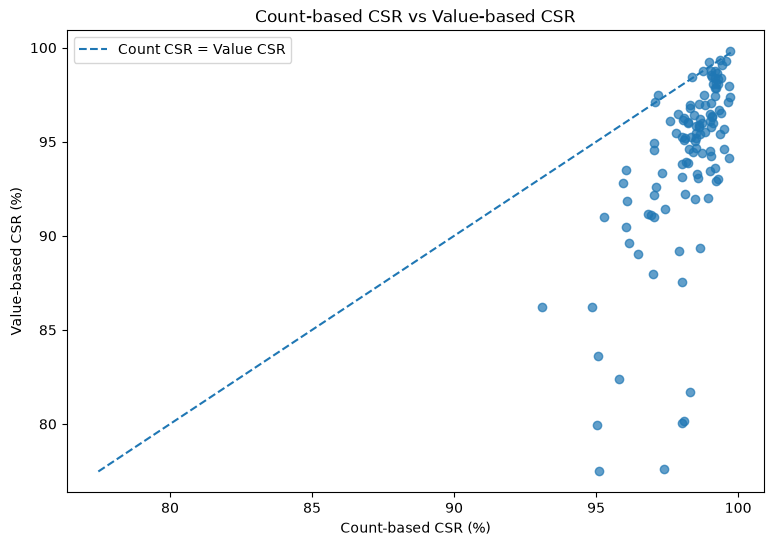

In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    q1_df["Count_CSR"],
    q1_df["Value_CSR"],
    alpha=0.7
)

min_val = min(
    q1_df["Count_CSR"].min(),
    q1_df["Value_CSR"].min()
)

max_val = max(
    q1_df["Count_CSR"].max(),
    q1_df["Value_CSR"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Count CSR = Value CSR"
)

plt.xlabel("Count-based CSR (%)")
plt.ylabel("Value-based CSR (%)")
plt.title("Count-based CSR vs Value-based CSR")
plt.legend()

plt.show()

----

### Q1.2 — Insurers with the Largest Count–Value Gap

The Count–Value Gap is used to identify insurer-year observations where
settlement performance differs most between claim count and claim value.

A positive gap indicates that the proportion of claims settled by count
is higher than the proportion of claim value settled.

In [21]:
gap_ranking = (
    q1_df[
        [
            "FY",
            "Insurer",
            "Count_CSR",
            "Value_CSR",
            "Count_Value_Gap",
            "Low_Volume_Flag"
        ]
    ]
    .sort_values("Count_Value_Gap", ascending=False)
)

gap_ranking.head(10)

,FY,Insurer,Count_CSR,Value_CSR,Count_Value_Gap,Low_Volume_Flag
68,2022-23,Shriram,97.401949,77.628282,19.773667,False
11,2020-21,HDFC Life,98.014844,80.061747,17.953098,False
93,2023-24,Shriram,98.089336,80.170136,17.919201,False
21,2020-21,Shriram,95.116658,77.475936,17.640721,False
119,2024-25,Shriram,98.309975,81.709049,16.600926,False
57,2022-23,Future Generali,95.040486,79.937796,15.102690,False
45,2021-22,Shriram,95.822677,82.393972,13.428704,False
3,2020-21,Ageas Federal,95.069252,83.627473,11.441779,False
23,2020-21,Tata AIA,98.020654,87.566123,10.454531,False
35,2021-22,HDFC Life,98.657916,89.376397,9.281519,False


### Gap distribution

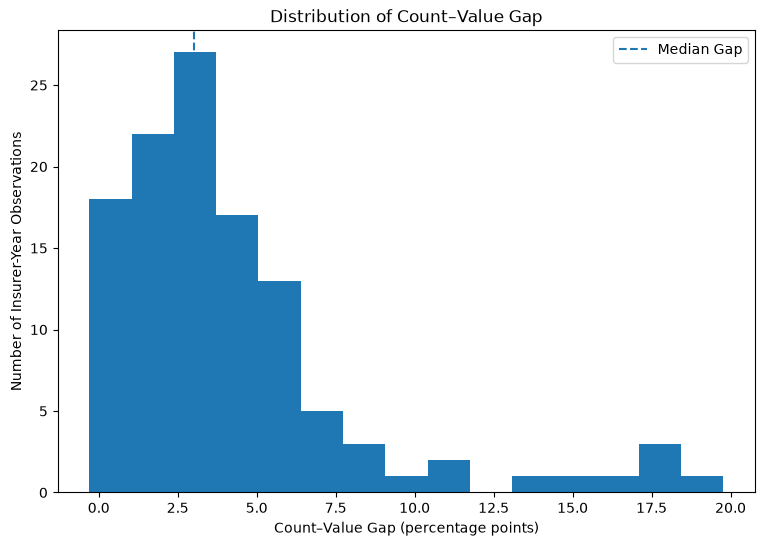

In [22]:
plt.figure(figsize=(9, 6))

plt.hist(
    q1_df["Count_Value_Gap"],
    bins=15
)

plt.axvline(
    q1_df["Count_Value_Gap"].median(),
    linestyle="--",
    label="Median Gap"
)

plt.xlabel("Count–Value Gap (percentage points)")
plt.ylabel("Number of Insurer-Year Observations")
plt.title("Distribution of Count–Value Gap")
plt.legend()

plt.show()

----

### Industry-level 5-year trend

In [23]:
yearly_gap = (
    q1_df
    .groupby("FY")["Count_Value_Gap"]
    .median()
    .reset_index()
)

yearly_gap

,FY,Count_Value_Gap
0,2020-21,4.694069
1,2021-22,2.884736
2,2022-23,4.269222
3,2023-24,3.041386
4,2024-25,1.773623


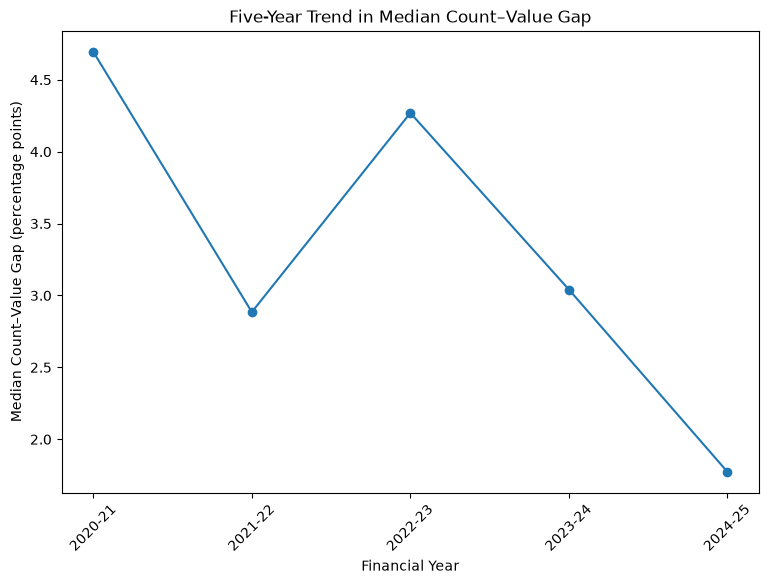

In [24]:
plt.figure(figsize=(9, 6))

plt.plot(
    yearly_gap["FY"],
    yearly_gap["Count_Value_Gap"],
    marker="o"
)

plt.xlabel("Financial Year")
plt.ylabel("Median Count–Value Gap (percentage points)")
plt.title("Five-Year Trend in Median Count–Value Gap")

plt.xticks(rotation=45)

plt.show()

### Q1.3 — Identifying the Largest Count–Value Gaps

While the overall distribution establishes whether Count–Value divergence
is widespread, insurer-level ranking helps identify the observations where
the difference is most pronounced.

The analysis focuses on the largest positive Count–Value Gaps while
retaining the Low_Volume_Flag as a reliability context.

In [25]:
gap_ranking = (
    q1_df[
        [
            "FY",
            "Insurer",
            "Count_CSR",
            "Value_CSR",
            "Count_Value_Gap",
            "Low_Volume_Flag"
        ]
    ]
    .sort_values("Count_Value_Gap", ascending=False)
)

gap_ranking.head(10)

,FY,Insurer,Count_CSR,Value_CSR,Count_Value_Gap,Low_Volume_Flag
68,2022-23,Shriram,97.401949,77.628282,19.773667,False
11,2020-21,HDFC Life,98.014844,80.061747,17.953098,False
93,2023-24,Shriram,98.089336,80.170136,17.919201,False
21,2020-21,Shriram,95.116658,77.475936,17.640721,False
119,2024-25,Shriram,98.309975,81.709049,16.600926,False
57,2022-23,Future Generali,95.040486,79.937796,15.102690,False
45,2021-22,Shriram,95.822677,82.393972,13.428704,False
3,2020-21,Ageas Federal,95.069252,83.627473,11.441779,False
23,2020-21,Tata AIA,98.020654,87.566123,10.454531,False
35,2021-22,HDFC Life,98.657916,89.376397,9.281519,False


### Q1.3— Largest Count–Value Gaps

The largest observed Count–Value Gaps are concentrated among a small
number of insurer-year observations. Several of the largest gaps are
associated with established-volume insurers rather than low-volume
observations, indicating that the divergence cannot be attributed only
to small claim volumes.

The ranking is used as a diagnostic to identify insurers requiring
further longitudinal investigation; it is not treated as a direct
measure of overall insurer quality.

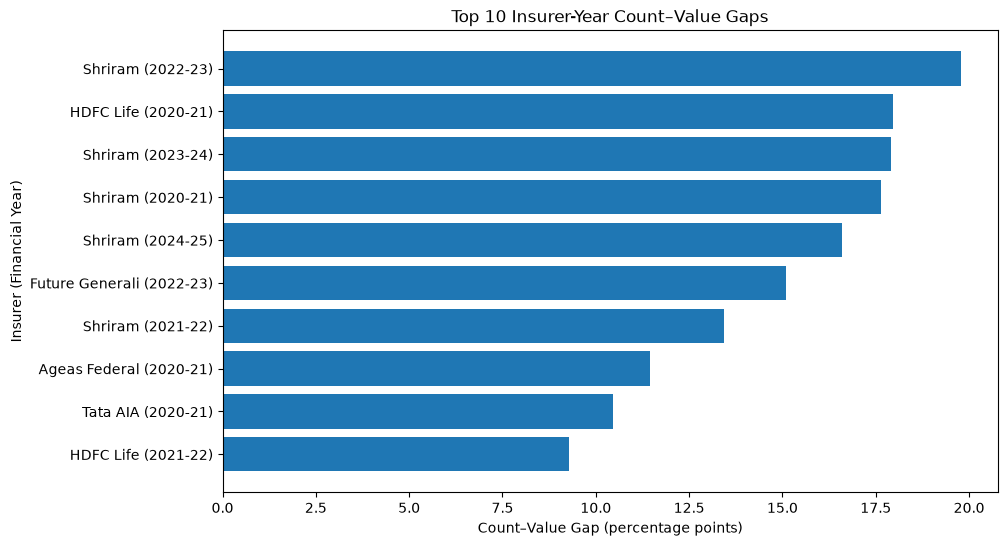

In [26]:
top_gap = gap_ranking.head(10).copy()

top_gap["Label"] = (
    top_gap["Insurer"] + " (" + top_gap["FY"] + ")"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_gap["Label"][::-1],
    top_gap["Count_Value_Gap"][::-1]
)

plt.xlabel("Count–Value Gap (percentage points)")
plt.ylabel("Insurer (Financial Year)")
plt.title("Top 10 Insurer-Year Count–Value Gaps")

plt.show()

### LARGE INSURER GAP 

In [27]:
large_gap_insurers = (
    gap_ranking[
        gap_ranking["Count_Value_Gap"] >= 10
    ]["Insurer"]
    .value_counts()
    .sort_values(ascending=False)
)

large_gap_insurers

Insurer
Shriram            5
HDFC Life          1
Future Generali    1
Ageas Federal      1
Tata AIA           1
Name: count, dtype: int64

In [28]:
large_gap = gap_ranking[
    gap_ranking["Count_Value_Gap"] >= 10
][
    [
        "FY",
        "Insurer",
        "Count_CSR",
        "Value_CSR",
        "Count_Value_Gap",
        "Low_Volume_Flag"
    ]
]

large_gap

,FY,Insurer,Count_CSR,Value_CSR,Count_Value_Gap,Low_Volume_Flag
68,2022-23,Shriram,97.401949,77.628282,19.773667,False
11,2020-21,HDFC Life,98.014844,80.061747,17.953098,False
93,2023-24,Shriram,98.089336,80.170136,17.919201,False
21,2020-21,Shriram,95.116658,77.475936,17.640721,False
119,2024-25,Shriram,98.309975,81.709049,16.600926,False
57,2022-23,Future Generali,95.040486,79.937796,15.102690,False
45,2021-22,Shriram,95.822677,82.393972,13.428704,False
3,2020-21,Ageas Federal,95.069252,83.627473,11.441779,False
23,2020-21,Tata AIA,98.020654,87.566123,10.454531,False


----

### Q1 — Key Insight

The analysis shows a consistent difference between claim settlement
performance measured by claim count and by claim value.

Across the valid insurer-year observations, the median Count_CSR was
approximately 98.5%, compared with 95.3% for Value_CSR, resulting in a
median Count–Value Gap of approximately 3 percentage points.

Most insurer-year observations show relatively moderate gaps, but a
smaller set exhibits substantially larger divergences, with the largest
observed gap reaching approximately 19.8 percentage points.

Notably, Shriram appears repeatedly among the highest-gap observations,
accounting for 5 of the 9 insurer-year observations with gaps of at least
10 percentage points. These observations were not flagged as low-volume,
indicating that large divergence is not limited to low-volume insurers.

The five-year median gap also declined overall, from approximately
4.7 percentage points in FY 2020-21 to 1.8 percentage points in
FY 2024-25, although the trend was not consistently downward every year.

### Business Interpretation

A high count-based settlement ratio does not necessarily imply an
equally strong settlement outcome when measured by claim value. This
suggests that claim-count-based reporting alone may not fully capture
differences in the monetary value of claims settled.

### Limitation

The Count–Value Gap is a diagnostic measure and should not be interpreted
as a standalone measure of insurer quality. Differences may reflect
claim-size composition, business mix, or the timing and characteristics
of claims. Persistent insurer-level patterns are investigated separately
in Q2.

----

# Q2 — Persistent Count–Value Divergence

## Business Question

Which insurers show persistent Count–Value divergence across the
five-year period, rather than an isolated one-year deviation?

## Objective

To identify insurers whose Count–Value Gap remains consistently elevated
across multiple financial years and distinguish persistent patterns from
short-term deviations.

## Why This Matters

A large gap in a single financial year may reflect temporary claim
composition or other year-specific factors.

A repeatedly large gap across multiple years provides stronger evidence
of a persistent difference between count-based and value-based settlement
performance.

## Methodology

The analysis will:

1. Calculate the number of available years for each insurer.
2. Measure the insurer's median Count–Value Gap across available years.
3. Measure the variability of the gap across years.
4. Examine the year-by-year trajectory of insurers with elevated gaps.

Insurers with insufficient observations will not be classified as
persistent performers.

----

In [29]:
q2_summary = (
    q1_df
    .groupby("Insurer")
    .agg(
        Years=("FY", "nunique"),
        Median_Gap=("Count_Value_Gap", "median"),
        Mean_Gap=("Count_Value_Gap", "mean"),
        Gap_Std=("Count_Value_Gap", "std"),
        Max_Gap=("Count_Value_Gap", "max")
    )
    .sort_values("Median_Gap", ascending=False)
)

q2_summary

,Years,Median_Gap,Mean_Gap,Gap_Std,Max_Gap
Insurer,,,,,
Shriram,5,17.640721,17.072644,2.336435,19.773667
Future Generali,5,6.558251,7.261625,5.067255,15.102690
Bajaj Allianz,5,6.247115,5.885915,0.709513,6.509633
Ageas Federal,5,6.012771,6.635067,3.195992,11.441779
India First,5,4.877148,4.561005,1.449215,5.825071
Reliance Nippon,5,4.340646,4.697648,1.511548,6.889885
Exide Life,2,4.026329,4.026329,1.734966,5.253135
Aditya Birla Sun Life,5,3.926127,3.811784,1.655933,5.889136
Tata AIA,5,3.871921,4.592010,3.527613,10.454531


In [30]:
q2_summary["Years"].value_counts().sort_index()

Years
2     1
3     1
5    22
Name: count, dtype: int64

In [31]:
q2_complete = (
    q2_summary[
        q2_summary["Years"] == q1_df["FY"].nunique()
    ]
    .sort_values("Median_Gap", ascending=False)
)

q2_complete

,Years,Median_Gap,Mean_Gap,Gap_Std,Max_Gap
Insurer,,,,,
Shriram,5,17.640721,17.072644,2.336435,19.773667
Future Generali,5,6.558251,7.261625,5.067255,15.102690
Bajaj Allianz,5,6.247115,5.885915,0.709513,6.509633
Ageas Federal,5,6.012771,6.635067,3.195992,11.441779
India First,5,4.877148,4.561005,1.449215,5.825071
Reliance Nippon,5,4.340646,4.697648,1.511548,6.889885
Aditya Birla Sun Life,5,3.926127,3.811784,1.655933,5.889136
Tata AIA,5,3.871921,4.592010,3.527613,10.454531
HDFC Life,5,3.793171,7.126146,6.712090,17.953098


----

### Q2.1 — Five-Year Count–Value Gap Trajectory

To distinguish persistent divergence from isolated annual deviations, the
Count–Value Gap is examined across all available financial years.

The primary longitudinal analysis focuses on insurers with complete
five-year coverage. This avoids comparing insurers with materially
different observation periods.

Insurer-level median gap is used to identify insurers with consistently
higher divergence, while the year-by-year trajectory is examined to
understand whether the gap is stable, improving, worsening, or volatile.

### Top 5 complete insurers

In [32]:
top_persistent = (
    q2_complete
    .head(5)
    .index
)

top_persistent

Index(['Shriram', 'Future Generali', 'Bajaj Allianz', 'Ageas Federal',
       'India First'],
      dtype='str', name='Insurer')

### create trajectory table

In [33]:
q2_trend = (
    q1_df[
        q1_df["Insurer"].isin(top_persistent)
    ]
    .pivot(
        index="FY",
        columns="Insurer",
        values="Count_Value_Gap"
    )
)

q2_trend

Insurer,Ageas Federal,Bajaj Allianz,Future Generali,India First,Shriram
FY,,,,,
2020-21,11.441779,6.509633,8.617740,5.649574,17.640721
2021-22,6.012771,5.570707,6.558251,5.825071,13.428704
2022-23,5.578850,4.786034,15.102690,4.877148,19.773667
2023-24,7.453962,6.316088,4.202123,4.215785,17.919201
2024-25,2.687973,6.247115,1.827320,2.237447,16.600926


### trajectory chart

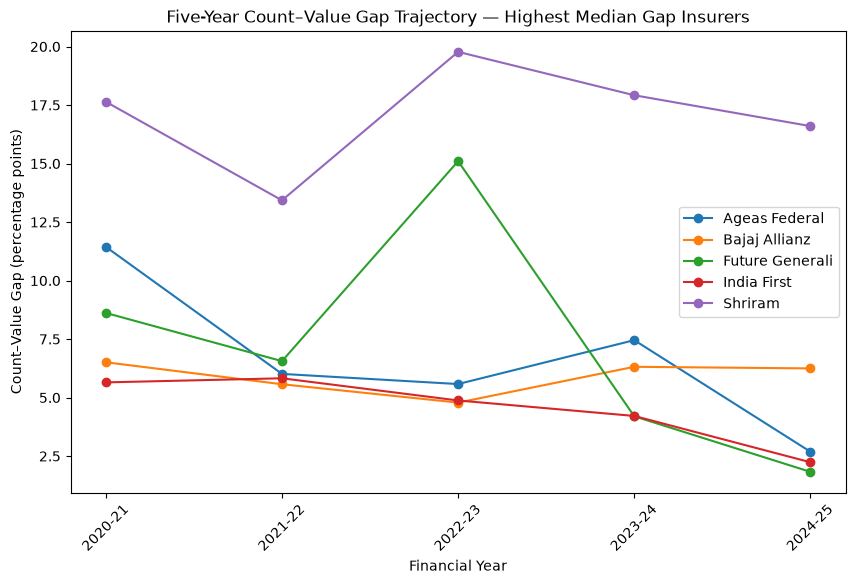

In [34]:
plt.figure(figsize=(10, 6))

for insurer in q2_trend.columns:
    plt.plot(
        q2_trend.index,
        q2_trend[insurer],
        marker="o",
        label=insurer
    )

plt.xlabel("Financial Year")
plt.ylabel("Count–Value Gap (percentage points)")
plt.title("Five-Year Count–Value Gap Trajectory — Highest Median Gap Insurers")

plt.xticks(rotation=45)
plt.legend()

plt.show()

----

### Q2.2 — Persistence Assessment

The five-year trajectories show that a high Count–Value Gap can arise
through different patterns: persistent divergence, temporary spikes,
stable moderate divergence, or gradual improvement.

To avoid relying only on visual interpretation, the selected insurers
are evaluated using their first-year gap, latest-year gap, median gap,
and the number of years in which the gap exceeded 10 percentage points.

In [35]:
persistence_check = (
    q2_complete.loc[
        q2_complete.index.isin(top_persistent),
        ["Median_Gap", "Gap_Std", "Max_Gap"]
    ]
    .copy()
)

persistence_check["First_Year_Gap"] = (
    q1_df[
        q1_df["Insurer"].isin(top_persistent)
    ]
    .sort_values("FY")
    .groupby("Insurer")["Count_Value_Gap"]
    .first()
)

persistence_check["Latest_Year_Gap"] = (
    q1_df[
        q1_df["Insurer"].isin(top_persistent)
    ]
    .sort_values("FY")
    .groupby("Insurer")["Count_Value_Gap"]
    .last()
)

persistence_check["Years_Gap_Above_10"] = (
    q1_df[
        (q1_df["Insurer"].isin(top_persistent)) &
        (q1_df["Count_Value_Gap"] >= 10)
    ]
    .groupby("Insurer")
    .size()
)

persistence_check = persistence_check.sort_values(
    "Median_Gap",
    ascending=False
)

persistence_check

,Median_Gap,Gap_Std,Max_Gap,First_Year_Gap,Latest_Year_Gap,Years_Gap_Above_10
Insurer,,,,,,
Shriram,17.640721,2.336435,19.773667,17.640721,16.600926,5.0
Future Generali,6.558251,5.067255,15.102690,8.617740,1.827320,1.0
Bajaj Allianz,6.247115,0.709513,6.509633,6.509633,6.247115,NaN
Ageas Federal,6.012771,3.195992,11.441779,11.441779,2.687973,1.0
India First,4.877148,1.449215,5.825071,5.649574,2.237447,NaN


---

### Q2 — Key Insight

The five-year analysis shows that large Count–Value Gaps can follow
different patterns across insurers.

Shriram demonstrates the clearest persistent divergence. Its
Count–Value Gap remained above 10 percentage points in all five
financial years, with a five-year median gap of approximately
17.6 percentage points. The gap remained elevated even in FY 2024-25
at approximately 16.6 percentage points.

In contrast, Future Generali and Ageas Federal recorded isolated years
of large divergence but showed substantially lower gaps in later years.
India First shows a generally improving pattern, while Bajaj Allianz
maintains a relatively stable but moderate gap.

### Business Interpretation

A large Count–Value Gap should not automatically be interpreted as a
persistent insurer-level issue. Longitudinal analysis distinguishes
persistent divergence from temporary spikes and stable moderate gaps.

The repeated divergence observed for Shriram warrants further
investigation into whether claim-value composition, repudiation,
pending claims, or other claims characteristics contribute to the
pattern.

### Limitation

The analysis identifies association and persistence in observed
metrics but does not establish the underlying cause of the
Count–Value Gap. Claim mix, claim severity, business composition and
other operational factors may influence the observed difference.
Further analysis is required before attributing the divergence to
specific insurer practices.

---

## Q3 — Industry-wide Unclaimed Claims Trend

### Business Question

Has the typical insurer's Unclaimed Ratio improved or worsened
over the five-year period?

### Objective

To examine the year-wise trend in Unclaimed Ratio across the
Life insurance industry and determine whether the typical
insurer is experiencing a decline or increase in the proportion
of unclaimed claims.

### Why This Matters

Unclaimed claims represent claims that remain unclaimed relative
to the total claims observed.

Examining the trend over multiple financial years can indicate
whether the proportion of unclaimed claims is changing over time
across the Life insurance industry.

A five-year industry-level view also helps distinguish a
year-specific movement from a broader trend.

### Metrics

- Unclaimed_Ratio
- FY
- Insurer
- Low_Volume_Flag

---

### Validate

In [36]:
# Unclaimed ratio

df[df["Unclaimed_Ratio"] > 0][["FY","Insurer","Unclaimed_Ratio"]]

,FY,Insurer,Unclaimed_Ratio
0,2020-21,LIC,1.237821
10,2020-21,Future Generali,0.005280
11,2020-21,HDFC Life,0.241867
12,2020-21,ICICI Prudential,0.008754
20,2020-21,SBI Life,1.112673
24,2021-22,LIC,1.560407
35,2021-22,HDFC Life,0.193827
36,2021-22,ICICI Prudential,0.024839
40,2021-22,PNB Met Life,0.282745
42,2021-22,Reliance Nippon,0.442501


In [37]:
df["Unclaimed_Ratio"].describe()

count    116.000000
mean       0.077641
std        0.245137
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.560407
Name: Unclaimed_Ratio, dtype: float64

In [38]:
# Checking year wise median and count

df.groupby("FY")["Unclaimed_Ratio"].agg([
    "median",
    "count"
])

,median,count
FY,,
2020-21,0.0,24
2021-22,0.0,24
2022-23,0.0,23
2023-24,0.0,22
2024-25,0.0,23


In [39]:
# filtering

filter_df = df[df["Unclaimed_Ratio"] > 0]
filter_df

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate
0,2020-21,LIC,5875,349.690000,941101,18755.650000,946976,19105.340000,933889,18295.580000,...,0.0,0.0,False,98.618022,95.761604,2.856418,1.237821,0.182159,0.000000,0.689669
10,2020-21,Future Generali,3,0.311350,1223,55.473135,1226,55.784485,1163,48.110547,...,0.0,0.0,False,94.861338,86.243598,8.617740,0.005280,0.652529,0.000000,4.486134
11,2020-21,HDFC Life,35,17.578717,16941,1277.962532,16976,1295.541249,16639,1037.232954,...,5.0,0.0,False,98.014844,80.061747,17.953098,0.241867,1.048539,0.000000,0.494816
12,2020-21,ICICI Prudential,95,43.701627,14734,1643.048773,14829,1686.750400,14518,1504.643618,...,1.0,0.0,False,97.902758,89.203691,8.699067,0.008754,0.107897,0.000000,1.948884
20,2020-21,SBI Life,36,7.776073,34183,1614.551157,34219,1622.327230,31855,1398.775249,...,5.0,1.0,False,93.091557,86.220290,6.871267,1.112673,2.665186,0.109649,3.804904
24,2021-22,LIC,1725,292.420000,1365379,29293.460000,1367104,29585.880000,1349865,28408.380000,...,0.0,0.0,False,98.739013,96.020061,2.718952,1.560407,0.166922,0.000000,0.637333
35,2021-22,HDFC Life,178,167.238488,26944,2751.005783,27122,2918.244272,26758,2608.221587,...,0.0,0.0,False,98.657916,89.376397,9.281519,0.193827,0.084802,0.000000,0.501438
36,2021-22,ICICI Prudential,16,7.823212,22265,3110.215872,22281,3118.039084,21795,2977.495652,...,36.0,3.0,False,97.818769,95.492570,2.326199,0.024839,0.359050,3.750000,1.786275
40,2021-22,PNB Met Life,0,0.000000,8586,717.426852,8586,717.426852,8357,669.690508,...,1.0,0.0,False,97.332867,93.346173,3.986695,0.282745,0.023294,0.000000,2.608898
42,2021-22,Reliance Nippon,4,1.481905,13726,359.281149,13730,360.763055,13548,344.142903,...,0.0,0.0,False,98.674436,95.393056,3.281379,0.442501,0.021850,0.000000,1.267298


In [40]:
# checking for non zero unclaimed ratio each year

filter2 = filter_df.groupby("FY")["Unclaimed_Ratio"].count()
filter2

FY
2020-21    5
2021-22    6
2022-23    6
2023-24    5
2024-25    5
Name: Unclaimed_Ratio, dtype: int64

- Although the median Unclaimed Ratio remained at 0% across all five years, non-zero ratios were reported in roughly one-fifth to one-quarter of insurer-year observations, peaking in FY 2022-23 before declining in the subsequent two years.

In [41]:
# year-wise typical ratio

unclaimed_ratio_filtered = (filter_df.groupby("FY")["Unclaimed_Ratio"].median().reset_index())
unclaimed_ratio_filtered

,FY,Unclaimed_Ratio
0,2020-21,0.241867
1,2021-22,0.324239
2,2022-23,0.110759
3,2023-24,0.160821
4,2024-25,0.037943


---

### Visualization

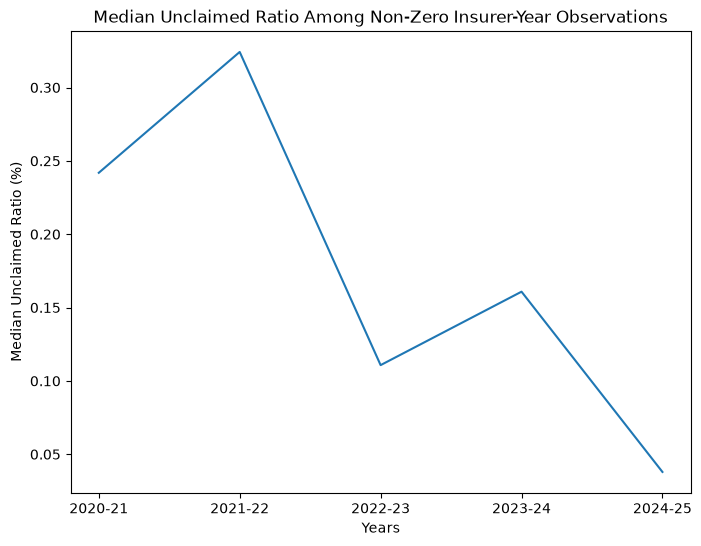

In [42]:
plt.figure(figsize=(8,6))

sns.lineplot(
    x="FY",
    y="Unclaimed_Ratio",
    data=unclaimed_ratio_filtered
)

plt.title("Median Unclaimed Ratio Among Non-Zero Insurer-Year Observations")
plt.xlabel("Years")
plt.ylabel("Median Unclaimed Ratio (%)")

plt.show()


### 2020-21 vs 2024-25 comparison

In [43]:
difference = unclaimed_ratio_filtered.iloc[0,1] - unclaimed_ratio_filtered.iloc[4,1]
difference 

np.float64(0.20392455854482672)

### percentage change

In [44]:
change = (
    (unclaimed_ratio_filtered.iloc[4,1]
     - unclaimed_ratio_filtered.iloc[0,1])
    / unclaimed_ratio_filtered.iloc[0,1]
) * 100

change

np.float64(-84.31255225831592)

### creating a supporting table 

In [45]:
filter1 = df.groupby("FY")["Unclaimed_Ratio"].count().reset_index()
filter1

filter2 = filter_df.groupby("FY")["Unclaimed_Ratio"].count()
filter2

non_zero_summary = pd.merge(filter1 , filter2 , on="FY")
non_zero_summary

non_zero_summary["Non zero %"]= non_zero_summary["Unclaimed_Ratio_y"] / non_zero_summary["Unclaimed_Ratio_x"] * 100
non_zero_summary

,FY,Unclaimed_Ratio_x,Unclaimed_Ratio_y,Non zero %
0,2020-21,24,5,20.833333
1,2021-22,24,6,25.000000
2,2022-23,23,6,26.086957
3,2023-24,22,5,22.727273
4,2024-25,23,5,21.739130


----

### Key Insight

The analysis shows that the overall median Unclaimed Ratio remained at 0% across all five financial years. This indicates that more than half of the valid insurer-year observations reported a zero Unclaimed Ratio.

However, non-zero Unclaimed Ratios were present in a smaller proportion of insurer-year observations. The share of non-zero observations ranged from approximately 20.8% to 26.1%, reaching its highest level in FY 2022-23 at 26.1%.

Among the insurer-year observations with a non-zero Unclaimed Ratio, the median ratio increased from 0.242% in FY 2020-21 to 0.324% in FY 2021-22. It then declined to 0.111% in FY 2022-23, increased slightly to 0.161% in FY 2023-24, and declined further to 0.038% in FY 2024-25.

Between FY 2020-21 and FY 2024-25, the median Unclaimed Ratio among non-zero observations declined by approximately 0.204 percentage points, representing a relative decline of approximately 84.3%.

### Business Interpretation

Unclaimed Ratios were not widespread across the industry, as the majority of insurer-year observations reported zero values.

Within the smaller group of observations reporting a non-zero ratio, the typical ratio was substantially lower in FY 2024-25 than in FY 2020-21. However, the year-wise pattern was not continuously declining, with increases observed in FY 2021-22 and FY 2023-24.

Therefore, the data indicates an overall reduction between the beginning and end of the study period rather than a consistent year-on-year decline.

### Limitation

The analysis describes patterns in reported Unclaimed Ratios but does not establish the reasons behind the observed changes.

The overall median is strongly influenced by the large number of zero observations. Therefore, non-zero observations were analysed separately to provide additional context.

The observed decline should not be interpreted as evidence of causation or attributed to any specific regulatory, operational, or insurer-level factor without further analysis.

---

## Q4 — Claims Volume vs Count–Value Gap Stability

### Business Question

Are insurers with lower claims volume more likely to show greater
year-to-year volatility in their Count–Value Gap?

### Objective

To examine whether an insurer's claims volume is associated with
the stability of its Count–Value Gap across the five-year period.

The analysis will compare each insurer's average claims volume with
the year-to-year variability of its Count–Value Gap.

### Why This Matters

The Count–Value Gap can vary across financial years, and the
magnitude of this variation may differ between insurers.

If lower-volume insurers show greater variability, claims volume
may be an important contextual factor when interpreting insurer-level
differences in the Count–Value Gap.

This analysis therefore helps distinguish relatively stable
patterns from highly variable ones across insurers.

### Metrics

- `total_claims_count` — used to measure average claims volume
- `Count_Value_Gap` — used to measure the difference between
  count-based and value-based settlement performance
- Standard deviation of `Count_Value_Gap` — used as the measure
  of gap volatility
- `Insurer` — used as the grouping variable


----

In [46]:
df.groupby("Insurer").agg({
    'total_claims_count' : "mean",
    'Count_Value_Gap' : "std"
}).sort_values(by="total_claims_count")

,total_claims_count,Count_Value_Gap
Insurer,,
Acko Life,0.0,NaN
Credit Access Life,0.0,NaN
Godigit Life,1.5,NaN
Bandhan,419.4,2.392976
Edelweiss Life,615.8,3.409114
Sahara,677.0,0.895100
Pramerica Life,786.0,0.278917
Aviva,1013.4,1.247436
Future Generali,1157.0,5.067255


In [47]:
# checking the valid years for each insurer 

df.groupby("Insurer")["Count_Value_Gap"].count().sort_values()


Insurer
Acko Life                0
Credit Access Life       0
Godigit Life             1
Exide Life               2
Sahara                   3
Axis Max Life            5
Ageas Federal            5
Aditya Birla Sun Life    5
Bharti Axa               5
Bandhan                  5
Bajaj Allianz            5
Canara HSBC              5
Edelweiss Life           5
Future Generali          5
HDFC Life                5
Aviva                    5
ICICI Prudential         5
India First              5
LIC                      5
Kotak Mahindra           5
PNB Met Life             5
Pramerica Life           5
Reliance Nippon          5
SBI Life                 5
Shriram                  5
Star Union               5
Tata AIA                 5
Name: Count_Value_Gap, dtype: int64

In [48]:
# filtering eligible insurer

f1 = df.groupby("Insurer")["Count_Value_Gap"].count().reset_index()

f1 = f1[f1["Count_Value_Gap"] == 5]
f1

q4_df = df[df["Insurer"].isin(f1["Insurer"])]

q4_df

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate
0,2020-21,LIC,5875,349.690000,941101,18755.650000,946976,19105.340000,933889,18295.580000,...,0.0,0.0,False,98.618022,95.761604,2.856418,1.237821,0.182159,0.000000,0.689669
1,2020-21,Aditya Birla Sun Life,19,3.802883,6455,468.846357,6474,472.649240,6347,440.264288,...,0.0,0.0,False,98.038307,93.148206,4.890101,0.000000,0.169910,0.000000,1.791783
2,2020-21,Bandhan,0,0.000000,401,107.440000,401,107.440000,398,105.980000,...,0.0,0.0,True,99.251870,98.641102,0.610768,0.000000,0.000000,NaN,0.748130
3,2020-21,Ageas Federal,5,1.255000,1800,87.051683,1805,88.306683,1716,73.848647,...,0.0,0.0,False,95.069252,83.627473,11.441779,0.000000,2.770083,0.000000,2.105263
4,2020-21,Aviva,5,0.778359,1050,116.371251,1055,117.149610,1034,111.572118,...,0.0,0.0,False,98.009479,95.239000,2.770478,0.000000,0.000000,NaN,1.990521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2024-25,Reliance Nippon,11,2.450686,8365,244.134678,8376,246.585364,8286,226.946359,...,0.0,0.0,False,98.925501,92.035616,6.889885,0.030304,0.011939,0.000000,1.050621
118,2024-25,SBI Life,118,23.580493,44831,2598.751947,44949,2622.332439,44205,2497.939508,...,34.0,2.0,False,98.344791,95.256401,3.088390,0.290204,0.367083,1.212121,1.165766
119,2024-25,Shriram,6,0.294771,4846,180.195625,4852,180.490395,4770,147.476986,...,0.0,0.0,False,98.309975,81.709049,16.600926,0.000000,0.144270,0.000000,1.401484
120,2024-25,Star Union,3,0.805000,2410,144.384758,2413,145.189758,2385,140.738808,...,0.0,0.0,False,98.839619,96.934391,1.905228,0.000000,0.082884,0.000000,1.077497


In [49]:
# insurer level analytics

q4_summary = q4_df.groupby("Insurer").agg({
    "total_claims_count" : "mean",
    "Count_Value_Gap" : "std"
}).sort_values(ascending=False,by="total_claims_count")

q4_summary

,total_claims_count,Count_Value_Gap
Insurer,,
LIC,990072.0,0.690349
SBI Life,42049.4,2.002426
Axis Max Life,22121.8,1.100822
HDFC Life,20164.2,6.712090
Bajaj Allianz,15957.6,0.709513
ICICI Prudential,15474.2,3.299058
Reliance Nippon,9691.2,1.511548
Aditya Birla Sun Life,7092.2,1.655933
Tata AIA,6640.0,3.527613


### Visualization

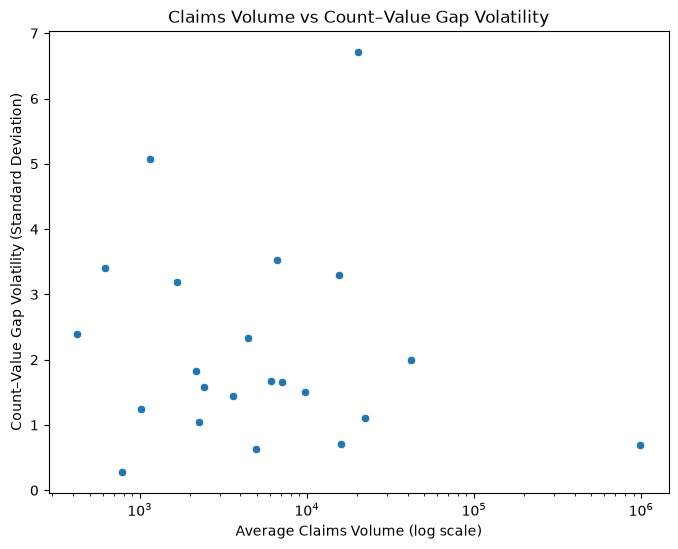

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="total_claims_count",
    y="Count_Value_Gap",
    data=q4_summary
)

plt.xscale("log")

plt.title("Claims Volume vs Count–Value Gap Volatility")

plt.xlabel("Average Claims Volume (log scale)")
plt.ylabel("Count–Value Gap Volatility (Standard Deviation)")

plt.show()

### Pearson correlation

In [51]:
q4_summary["total_claims_count"].corr(
    q4_summary["Count_Value_Gap"]
)

np.float64(-0.20608467910556755)

### — Key Insight

The analysis examined 22 insurers with complete five-year
Count–Value Gap observations to assess whether claims volume was
associated with the stability of the Count–Value Gap.

The scatter plot shows substantial variation in gap volatility
among lower-volume insurers. Some lower-volume insurers exhibit
relatively low volatility, while others show substantially higher
year-to-year variation.

The Pearson correlation between average claims volume and
Count–Value Gap volatility was approximately -0.21, indicating a
weak negative linear association.

This suggests that higher claims volume was associated with
slightly lower Count–Value Gap volatility in the observed data,
but the relationship was weak and did not show a clear or
consistent volume–volatility pattern across insurers.

### Business Interpretation

Claims volume may provide useful context when interpreting
insurer-level Count–Value Gap stability.

However, the observed relationship is weak. Therefore, claims
volume alone should not be used to explain or predict the
stability of the Count–Value Gap.

The analysis also shows why low-volume insurers should be
interpreted carefully: some low-volume insurers displayed
substantially higher volatility, but this pattern was not
consistent across all low-volume insurers.

### Limitation

The analysis is based on 22 insurers with complete five-year
observations and uses standard deviation as the measure of
Count–Value Gap volatility.

The Pearson correlation measures only the linear association
between average claims volume and volatility. It does not
establish causation and may not capture non-linear relationships.

Other factors such as claim mix, insurer size, business
composition, and year-specific changes may also influence
Count–Value Gap volatility.

Therefore, the observed weak negative association should be
treated as an exploratory finding rather than evidence that
claims volume directly determines gap stability.

---

## Q5 — Pending Rate vs Long-Pending Share

### Business Question

Does a higher overall Pending Rate correspond to a higher share
of pending claims that remain outstanding for more than one year?

### Objective

To examine whether insurers with a higher overall Pending Rate
also tend to have a higher proportion of pending claims that have
remained outstanding for more than one year.

The analysis will compare Pending Rate with Long-Pending Share at
the insurer-year level.

### Why This Matters

Pending Rate indicates the overall proportion of claims that remain
pending.

However, the Pending Rate alone does not show how long those claims
have remained outstanding.

Long-Pending Share adds an ageing dimension by measuring the
proportion of pending claims that have remained outstanding for
more than one year.

Comparing these two measures can help determine whether a higher
overall pending burden is associated with a greater long-duration
pending burden.

### Metrics

- `Pending_Rate` — overall pending claims rate
- `Long_Pending_Share` — share of pending claims outstanding for
  more than one year
- `Insurer`
- `FY`

### Analytical Note

A higher Pending Rate will not automatically be assumed to imply a
higher Long-Pending Share.

The relationship will be determined from the observed insurer-year
data.

Zero values in Long-Pending Share will be retained because zero is
a valid observation and indicates that none of the pending claims
in that insurer-year observation were more than one year old.

---

### validate 

In [52]:
df[df['Pending_Rate'] == 0]["Pending_Rate"].count()

np.int64(32)

In [53]:
df[["Pending_Rate", "Long_Pending_Share"]].isna().sum()

Pending_Rate           6
Long_Pending_Share    38
dtype: int64

In [54]:
df[df["Long_Pending_Share"] == 0]["Long_Pending_Share"].count()

np.int64(66)

In [55]:
# Filtering data 

q5_df = df[df["Pending_Rate"].notna() & df["Long_Pending_Share"].notnull()] 
q5_df

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate
0,2020-21,LIC,5875,349.690000,941101,18755.650000,946976,19105.340000,933889,18295.580000,...,0.0,0.0,False,98.618022,95.761604,2.856418,1.237821,0.182159,0.000000,0.689669
1,2020-21,Aditya Birla Sun Life,19,3.802883,6455,468.846357,6474,472.649240,6347,440.264288,...,0.0,0.0,False,98.038307,93.148206,4.890101,0.000000,0.169910,0.000000,1.791783
3,2020-21,Ageas Federal,5,1.255000,1800,87.051683,1805,88.306683,1716,73.848647,...,0.0,0.0,False,95.069252,83.627473,11.441779,0.000000,2.770083,0.000000,2.105263
5,2020-21,Bajaj Allianz,2,0.650000,14331,445.886349,14333,446.536349,14115,410.676805,...,0.0,0.0,False,98.479034,91.969401,6.509633,0.000000,0.034885,0.000000,1.486081
7,2020-21,Canara HSBC,2,2.000000,1897,166.537924,1899,168.537924,1844,156.075726,...,0.0,0.0,False,97.103739,92.605701,4.498038,0.000000,1.316482,0.000000,1.579779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2024-25,Reliance Nippon,11,2.450686,8365,244.134678,8376,246.585364,8286,226.946359,...,0.0,0.0,False,98.925501,92.035616,6.889885,0.030304,0.011939,0.000000,1.050621
118,2024-25,SBI Life,118,23.580493,44831,2598.751947,44949,2622.332439,44205,2497.939508,...,34.0,2.0,False,98.344791,95.256401,3.088390,0.290204,0.367083,1.212121,1.165766
119,2024-25,Shriram,6,0.294771,4846,180.195625,4852,180.490395,4770,147.476986,...,0.0,0.0,False,98.309975,81.709049,16.600926,0.000000,0.144270,0.000000,1.401484
120,2024-25,Star Union,3,0.805000,2410,144.384758,2413,145.189758,2385,140.738808,...,0.0,0.0,False,98.839619,96.934391,1.905228,0.000000,0.082884,0.000000,1.077497


In [56]:
# validating

q5_df[q5_df["Pending_Rate"] == 0]

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate


In [57]:
q5_df[q5_df["Long_Pending_Share"] == 0]

,FY,Insurer,pending_start_count,pending_start_amount,intimated_count,intimated_amount,total_claims_count,total_claims_amount,paid_count,paid_amount,...,pending_6m_to_1y,pending_gt_1y,Low_Volume_Flag,Count_CSR,Value_CSR,Count_Value_Gap,Unclaimed_Ratio,Pending_Rate,Long_Pending_Share,Repudiation_Rate
0,2020-21,LIC,5875,349.690000,941101,18755.650000,946976,19105.340000,933889,18295.580000,...,0.0,0.0,False,98.618022,95.761604,2.856418,1.237821,0.182159,0.0,0.689669
1,2020-21,Aditya Birla Sun Life,19,3.802883,6455,468.846357,6474,472.649240,6347,440.264288,...,0.0,0.0,False,98.038307,93.148206,4.890101,0.000000,0.169910,0.0,1.791783
3,2020-21,Ageas Federal,5,1.255000,1800,87.051683,1805,88.306683,1716,73.848647,...,0.0,0.0,False,95.069252,83.627473,11.441779,0.000000,2.770083,0.0,2.105263
5,2020-21,Bajaj Allianz,2,0.650000,14331,445.886349,14333,446.536349,14115,410.676805,...,0.0,0.0,False,98.479034,91.969401,6.509633,0.000000,0.034885,0.0,1.486081
7,2020-21,Canara HSBC,2,2.000000,1897,166.537924,1899,168.537924,1844,156.075726,...,0.0,0.0,False,97.103739,92.605701,4.498038,0.000000,1.316482,0.0,1.579779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-25,Pramerica Life,1,0.074208,727,35.256420,728,35.330629,722,34.576985,...,0.0,0.0,False,99.175824,97.866884,1.308940,0.000000,0.137363,0.0,0.549451
116,2024-25,Reliance Nippon,11,2.450686,8365,244.134678,8376,246.585364,8286,226.946359,...,0.0,0.0,False,98.925501,92.035616,6.889885,0.030304,0.011939,0.0,1.050621
119,2024-25,Shriram,6,0.294771,4846,180.195625,4852,180.490395,4770,147.476986,...,0.0,0.0,False,98.309975,81.709049,16.600926,0.000000,0.144270,0.0,1.401484
120,2024-25,Star Union,3,0.805000,2410,144.384758,2413,145.189758,2385,140.738808,...,0.0,0.0,False,98.839619,96.934391,1.905228,0.000000,0.082884,0.0,1.077497


In [58]:
q5_df[["Pending_Rate","Long_Pending_Share"]].describe()

,Pending_Rate,Long_Pending_Share
count,84.000000,84.000000
mean,0.673463,9.226444
std,3.636589,22.426659
min,0.004987,0.000000
25%,0.049950,0.000000
50%,0.136158,0.000000
75%,0.309927,0.000000
max,33.333333,100.000000


### Visualization 

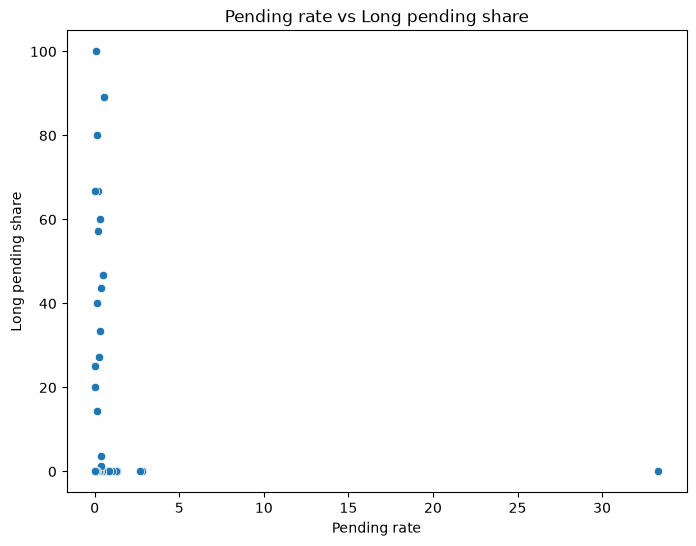

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Pending_Rate",
    y="Long_Pending_Share",
    data=q5_df
)

plt.title("Pending rate vs Long pending share")

plt.xlabel("Pending rate")
plt.ylabel("Long pending share")

plt.show()

### Correlation

In [60]:
q5_df["Pending_Rate"].corr(
    q5_df["Long_Pending_Share"],
    method="spearman"
)

np.float64(0.18754488441760597)

----

### — Key Insight

The analysis examined 84 insurer-year observations for which both
Pending Rate and Long-Pending Share were available.

The distribution shows that Long-Pending Share was zero in 66 of
the 84 observations, representing approximately 78.6% of the
valid paired observations. Only 18 observations reported a
non-zero Long-Pending Share.

The scatter plot shows substantial variation in Long-Pending Share
at relatively low Pending Rates, with observations ranging from
0% to 100%. The visual pattern does not indicate a strong or
consistent relationship between the two measures.

The Spearman correlation between Pending Rate and Long-Pending
Share was approximately 0.19, indicating a weak positive
monotonic association.

### Business Interpretation

The analysis suggests that overall pending burden and
long-duration pending exposure are related only weakly in the
observed insurer-year data.

A higher Pending Rate does not necessarily correspond to a
substantially higher Long-Pending Share. Many observations with
low Pending Rates have zero Long-Pending Share, while some
observations with relatively low Pending Rates still show
substantial long-pending exposure.

Therefore, overall Pending Rate alone does not fully capture the
ageing profile of pending claims. Long-Pending Share provides an
additional dimension for understanding the duration of pending
claims.

### Limitation

The analysis is based on 84 insurer-year observations where both
metrics were available. A substantial proportion of observations
(78.6%) had a zero Long-Pending Share, resulting in a
zero-concentrated distribution.

The Spearman correlation measures monotonic association and does
not establish causation.

Missing Long-Pending Share values were excluded because a valid
paired observation was required for the relationship analysis.
Therefore, the results describe the available paired observations
and may not represent insurer-year observations with missing
ageing information.

---

## Q6 — Count–Value Gap and Claim-Process Indicators

### Business Question

Do insurers with larger Count–Value Gaps also tend to show higher
claim-process indicators such as Repudiation Rate, Pending Rate,
or Unclaimed Ratio?

### Objective

To examine whether the divergence between claim settlement by count
and by value is associated with other claim-process indicators.

The analysis will compare Count_Value_Gap with:
- Repudiation_Rate
- Pending_Rate
- Unclaimed_Ratio

The objective is to identify whether larger Count–Value Gaps tend to
coexist with higher levels of these indicators across insurer-year
observations.

### Why This Matters

The Count–Value Gap highlights situations where the proportion of
claims settled by count differs from the proportion settled by value.

Examining its relationship with other claim-process indicators helps
determine whether this divergence is associated with broader claim
processing patterns.

This analysis is exploratory and identifies association rather than
causation.

### Metrics

- Count_Value_Gap
- Repudiation_Rate
- Pending_Rate
- Unclaimed_Ratio


### Limitation

Claim-process indicators may be affected by differences in insurer
size, claim mix, product portfolio, and reporting practices.

Therefore, observed relationships should be treated as exploratory
patterns rather than evidence that one metric causes another.

----

### validate

In [61]:
df[["Count_Value_Gap","Repudiation_Rate","Pending_Rate","Unclaimed_Ratio","Insurer","FY"]]

,Count_Value_Gap,Repudiation_Rate,Pending_Rate,Unclaimed_Ratio,Insurer,FY
0,2.856418,0.689669,0.182159,1.237821,LIC,2020-21
1,4.890101,1.791783,0.169910,0.000000,Aditya Birla Sun Life,2020-21
2,0.610768,0.748130,0.000000,0.000000,Bandhan,2020-21
3,11.441779,2.105263,2.770083,0.000000,Ageas Federal,2020-21
4,2.770478,1.990521,0.000000,0.000000,Aviva,2020-21
...,...,...,...,...,...,...
117,NaN,NaN,NaN,NaN,Sahara,2024-25
118,3.088390,1.165766,0.367083,0.290204,SBI Life,2024-25
119,16.600926,1.401484,0.144270,0.000000,Shriram,2024-25
120,1.905228,1.077497,0.082884,0.000000,Star Union,2024-25


In [ ]:
# Checking non null columns 

q6_df = df[["Count_Value_Gap","Repudiation_Rate","Pending_Rate","Unclaimed_Ratio","Insurer","FY"]]


q6_df[q6_df["Count_Value_Gap"].notna() & q6_df["Repudiation_Rate"].notna()].count()

Count_Value_Gap     116
Repudiation_Rate    116
Pending_Rate        116
Unclaimed_Ratio     116
Insurer             116
FY                  116
dtype: int64

In [63]:
q6_df[q6_df["Count_Value_Gap"].notna() & q6_df["Pending_Rate"].notna()].count()

Count_Value_Gap     116
Repudiation_Rate    116
Pending_Rate        116
Unclaimed_Ratio     116
Insurer             116
FY                  116
dtype: int64

In [64]:
q6_df[q6_df["Count_Value_Gap"].notna() & q6_df["Unclaimed_Ratio"].notna()].count()

Count_Value_Gap     116
Repudiation_Rate    116
Pending_Rate        116
Unclaimed_Ratio     116
Insurer             116
FY                  116
dtype: int64

In [65]:
# Descriptive summary 

q6_df.describe()

,Count_Value_Gap,Repudiation_Rate,Pending_Rate,Unclaimed_Ratio
count,116.000000,116.000000,116.000000,116.000000
mean,4.153878,2.039074,0.487680,0.077641
std,4.046813,6.136775,3.104228,0.245137
min,-0.297851,0.096167,0.000000,0.000000
25%,1.689739,0.799660,0.000000,0.000000
50%,2.999698,1.194237,0.067987,0.000000
75%,5.516924,1.865060,0.183848,0.000000
max,19.773667,66.666667,33.333333,1.560407


### Scatter plot

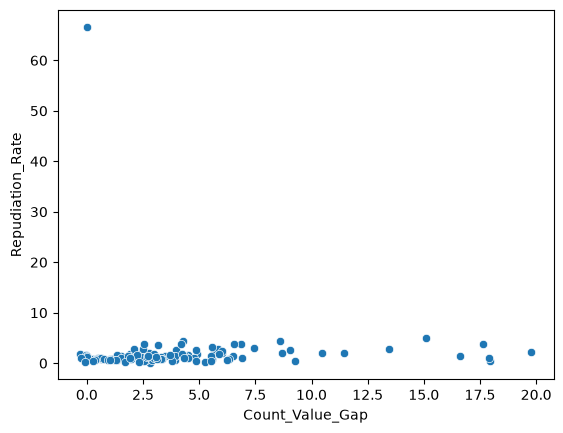

In [66]:
sns.scatterplot(
    x = "Count_Value_Gap",
    y = "Repudiation_Rate",
    data = q6_df
)

plt.show()

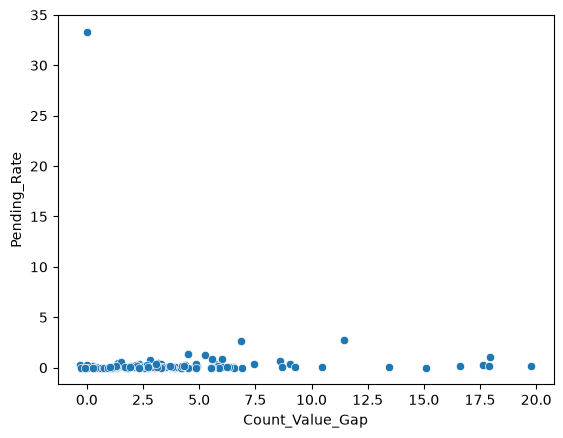

In [67]:
sns.scatterplot(
    x = "Count_Value_Gap",
    y = "Pending_Rate",
    data = q6_df
)

plt.show()

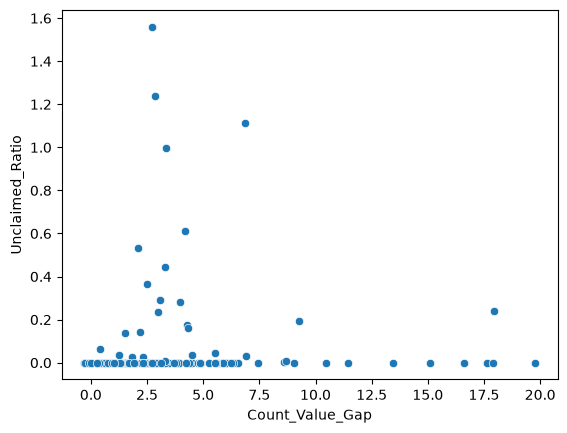

In [68]:
sns.scatterplot(
    x = "Count_Value_Gap",
    y = "Unclaimed_Ratio",
    data = q6_df
)

plt.show()

### Correlation 

In [69]:
corr = q6_df[["Count_Value_Gap","Repudiation_Rate","Pending_Rate","Unclaimed_Ratio"]].corr()

corr

,Count_Value_Gap,Repudiation_Rate,Pending_Rate,Unclaimed_Ratio
Count_Value_Gap,1.000000,-0.033124,-0.060161,-0.007229
Repudiation_Rate,-0.033124,1.000000,0.982662,-0.016630
Pending_Rate,-0.060161,0.982662,1.000000,-0.002394
Unclaimed_Ratio,-0.007229,-0.016630,-0.002394,1.000000


---

## Q6 second layer : High-Gap vs Lower-Gap

### Question 

Do observations with relatively high Count–Value Gaps show different claim-process indicator levels compared with observations having lower gaps?

----

### Step 1 Gap threshold determine 

In [70]:
high_gap = q6_df["Count_Value_Gap"].quantile(0.75)

lower_gap = q6_df["Count_Value_Gap"].quantile(0.25)

print("Top 75% : ",lower_gap)
print("Middle 50% :",q6_df["Count_Value_Gap"].median())
print("Bottom 25% : ",high_gap)

Top 75% :  1.6897386608520186
Middle 50% : 2.9996975334283107
Bottom 25% :  5.516923762123966


In [79]:
# High / Lower flag 

high1 = q6_df[q6_df["Count_Value_Gap"] >= 5.516 ]

In [72]:
low1 = q6_df[q6_df["Count_Value_Gap"] < 5.516 ]

In [83]:
# median for high and low 

high_gap_median = high1[["Repudiation_Rate","Pending_Rate","Unclaimed_Ratio"]].median()
    
low_gap_median = low1[["Repudiation_Rate","Pending_Rate","Unclaimed_Ratio"]].median()
    

print(high_gap_median,"\n",low_gap_median)

Repudiation_Rate    2.105263
Pending_Rate        0.107897
Unclaimed_Ratio     0.000000
dtype: float64 
 Repudiation_Rate    1.062417
Pending_Rate        0.062441
Unclaimed_Ratio     0.000000
dtype: float64


### Visualization 

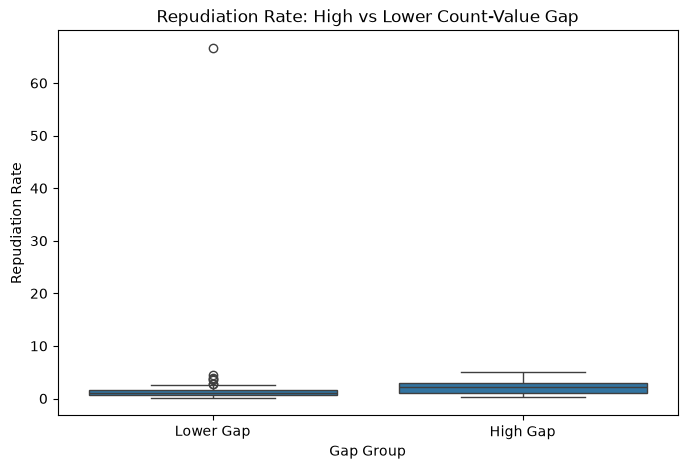

In [84]:
# 1. Repudiation Rate
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=q6_df.assign(
        Gap_Group=q6_df["Count_Value_Gap"].apply(
            lambda x: "High Gap" if x >= 5.516 else "Lower Gap"
        )
    ),
    x="Gap_Group",
    y="Repudiation_Rate"
)
plt.title("Repudiation Rate: High vs Lower Count-Value Gap")
plt.xlabel("Gap Group")
plt.ylabel("Repudiation Rate")
plt.show()

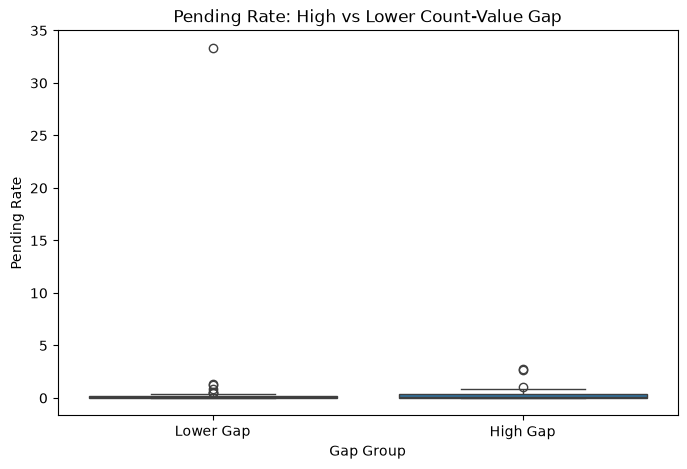

In [85]:
# 2. Pending Rate
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=q6_df.assign(
        Gap_Group=q6_df["Count_Value_Gap"].apply(
            lambda x: "High Gap" if x >= 5.516 else "Lower Gap"
        )
    ),
    x="Gap_Group",
    y="Pending_Rate"
)
plt.title("Pending Rate: High vs Lower Count-Value Gap")
plt.xlabel("Gap Group")
plt.ylabel("Pending Rate")
plt.show()

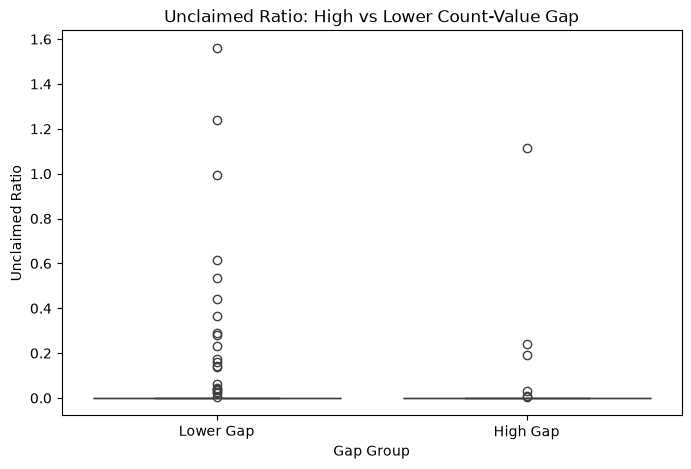

In [86]:
# 3. Unclaimed Ratio
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=q6_df.assign(
        Gap_Group=q6_df["Count_Value_Gap"].apply(
            lambda x: "High Gap" if x >= 5.516 else "Lower Gap"
        )
    ),
    x="Gap_Group",
    y="Unclaimed_Ratio"
)
plt.title("Unclaimed Ratio: High vs Lower Count-Value Gap")
plt.xlabel("Gap Group")
plt.ylabel("Unclaimed Ratio")
plt.show()

---

### Insight

The overall Pearson correlations between Count_Value_Gap and
Repudiation_Rate, Pending_Rate, and Unclaimed_Ratio were close to
zero, indicating no meaningful linear association at the overall
industry level.

However, a percentile-based comparison showed a different pattern.
The top 25% of observations by Count_Value_Gap had higher median
Repudiation_Rate and Pending_Rate than the lower-gap observations.

The median Repudiation_Rate was approximately 2.11% in the High Gap
group compared with 1.06% in the Lower Gap group.

Similarly, the median Pending_Rate was approximately 0.108% in the
High Gap group compared with 0.062% in the Lower Gap group.

Median Unclaimed_Ratio remained 0% in both groups.

This suggests that larger Count–Value Gaps may coexist with higher
typical repudiation and pending levels, while unclaimed behaviour
does not show a similar difference at the median level.

### Business Interpretation

Count–Value Gap should not be interpreted in isolation.

Although the overall linear relationships with the three claim-process
indicators were negligible, observations with relatively high
Count–Value Gaps showed higher typical repudiation and pending rates.

This indicates that high-gap observations may warrant additional
investigation of claim outcomes and ageing characteristics.

However, this analysis identifies an association rather than a causal
relationship. Statistical validation is required before treating these
patterns as significant drivers.

### Limitation

The analysis is based on insurer-year observations and uses exploratory
group comparisons.

The Repudiation_Rate and Pending_Rate distributions contain extreme
observations, while Unclaimed_Ratio is heavily concentrated at zero.

Therefore, median comparisons are used for robustness, and the observed
differences should not be interpreted as causal effects.

Further statistical validation will be performed in Phase 5.

----

# Thank You !

----